# UCI HAR Visualisation

This notebook loads UCI HAR through the project loader, keeping the same
total-acceleration harmonisation choices used elsewhere in the repo.


In [8]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

CWD = Path.cwd().resolve()
for candidate in (CWD, *CWD.parents):
    if (candidate / "pipeline").exists() and (candidate / "analysis").exists():
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate repo root from the current working directory.")

for extra_path in (REPO_ROOT, REPO_ROOT / "analysis"):
    extra_str = str(extra_path)
    if extra_str not in sys.path:
        sys.path.insert(0, extra_str)

import notebook_utils as nb_utils

nb_utils.configure_matplotlib()
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)


In [9]:
from pipeline.ingest import load_uci_har

DATASET_PATH = REPO_ROOT / "data" / "raw" / "UCIHAR_Dataset"
LOAD_FULL_DATASET = False
MAX_WINDOWS_PER_SPLIT = None if LOAD_FULL_DATASET else 250

if not DATASET_PATH.exists():
    raise FileNotFoundError(DATASET_PATH)

df = load_uci_har(DATASET_PATH, max_windows_per_split=MAX_WINDOWS_PER_SPLIT)
df = nb_utils.add_vector_magnitudes(df)
df["split"] = df["session_id"].astype(str).str.extract(r"^(train|test)_", expand=False).fillna("unknown")

print(f"Loaded {len(df):,} rows from {DATASET_PATH}")
display(df.head())


Loaded 64,000 rows from /home/joels/PycharmProjects/vulnerability_dissertation_clean/data/raw/UCIHAR_Dataset


,dataset_name,task_type,subject_id,session_id,timestamp,ax,ay,az,gx,gy,gz,label_raw,label_mapped,placement,sampling_rate_hz,source_file,row_index,acc_magnitude,gyro_magnitude,split
0,UCIHAR,har,1,train_w00000,0.00,9.932342,-1.208343,1.009439,0.030191,0.066014,0.022859,STANDING,static,waist,50.0,/home/joels/PycharmProjects/vulnerability_diss...,0,10.056365,0.076104,train
1,UCIHAR,har,1,train_w00000,0.02,10.030565,-1.244225,1.036437,0.043711,0.042699,0.010316,STANDING,static,waist,50.0,/home/joels/PycharmProjects/vulnerability_diss...,1,10.160440,0.061970,train
2,UCIHAR,har,1,train_w00000,0.04,10.022671,-1.216061,1.001283,0.035688,0.074850,0.013250,STANDING,static,waist,50.0,/home/joels/PycharmProjects/vulnerability_diss...,2,10.145704,0.083975,train
3,UCIHAR,har,1,train_w00000,0.06,9.981963,-1.225124,1.044925,0.040402,0.057320,0.017751,STANDING,static,waist,50.0,/home/joels/PycharmProjects/vulnerability_diss...,3,10.111004,0.072339,train
4,UCIHAR,har,1,train_w00000,0.08,10.038871,-1.233350,1.008256,0.047097,0.052343,0.002553,STANDING,static,waist,50.0,/home/joels/PycharmProjects/vulnerability_diss...,4,10.164481,0.070458,train


In [10]:
profile_df = nb_utils.dataset_profile(df)
loader_notes_df = pd.DataFrame({"loader_note": df.attrs.get("loader_notes", [])})
label_raw_df = nb_utils.count_table(df, "label_raw", top_n=10)
label_mapped_df = nb_utils.count_table(df, "label_mapped", top_n=10)

display(profile_df)
display(loader_notes_df if not loader_notes_df.empty else pd.DataFrame({"loader_note": ["No loader notes recorded"]}))
display(label_raw_df)
display(label_mapped_df)


,metric,value
0,rows,64000.00
1,columns,20.00
2,dataset_name_unique,1.00
3,task_type_unique,1.00
4,subject_id_unique,2.00
5,session_id_unique,500.00
6,source_file_unique,2.00
7,label_raw_unique,6.00
8,label_mapped_unique,3.00
9,sampling_rate_median_hz,50.00


,loader_note
0,UCI HAR loader uses total_acc_* signals for cr...
1,Accelerometer values are converted from g to m...
2,Gyroscope uses body_gyro_* signals from the so...


,label_raw,count,ratio
0,STANDING,13696,0.214
1,WALKING,13056,0.204
2,LAYING,12544,0.196
3,SITTING,11904,0.186
4,WALKING_UPSTAIRS,6528,0.102
5,WALKING_DOWNSTAIRS,6272,0.098


,label_mapped,count,ratio
0,static,38144,0.596
1,walking,13056,0.204
2,stairs,12800,0.2


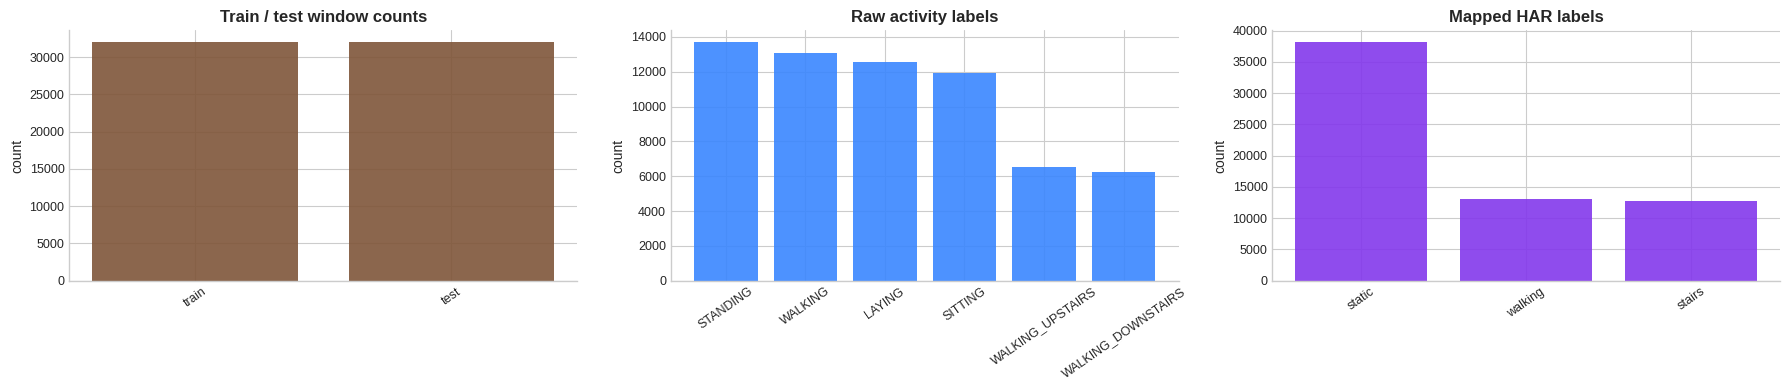

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
nb_utils.plot_count_bars(nb_utils.count_table(df, "split", top_n=None), "split", ax=axes[0], title="Train / test window counts", color="#7f5539")
nb_utils.plot_count_bars(label_raw_df, "label_raw", ax=axes[1], title="Raw activity labels", color="#3a86ff")
nb_utils.plot_count_bars(label_mapped_df, "label_mapped", ax=axes[2], title="Mapped HAR labels", color="#8338ec")
fig.tight_layout()


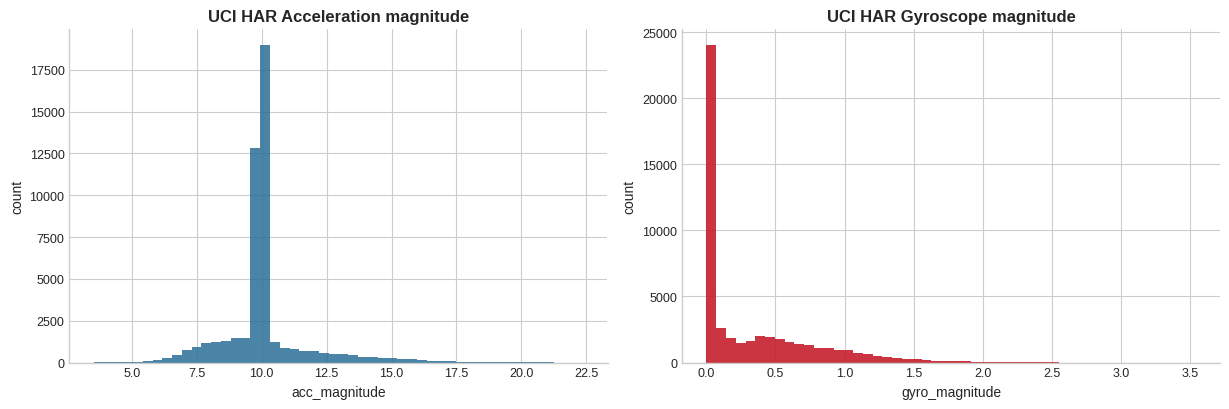

In [12]:
_ = nb_utils.plot_signal_histograms(df, dataset_label="UCI HAR")


,dataset_name,subject_id,session_id,source_file,start_ts,end_ts,n_rows,label_mapped,label_raw,duration_s
0,UCIHAR,1,train_w00000,/home/joels/PycharmProjects/vulnerability_diss...,0.0,2.54,128,static,STANDING,2.54
1,UCIHAR,1,train_w00001,/home/joels/PycharmProjects/vulnerability_diss...,0.0,2.54,128,static,STANDING,2.54
2,UCIHAR,1,train_w00002,/home/joels/PycharmProjects/vulnerability_diss...,0.0,2.54,128,static,STANDING,2.54
3,UCIHAR,1,train_w00003,/home/joels/PycharmProjects/vulnerability_diss...,0.0,2.54,128,static,STANDING,2.54
4,UCIHAR,1,train_w00004,/home/joels/PycharmProjects/vulnerability_diss...,0.0,2.54,128,static,STANDING,2.54


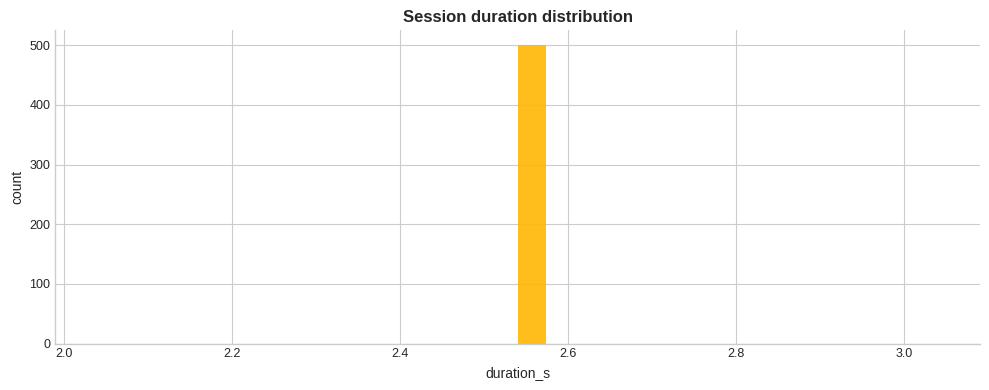

In [13]:
duration_df = nb_utils.session_duration_table(df)
display(duration_df.head())

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(duration_df["duration_s"].dropna(), bins=30, color="#ffb703", alpha=0.9)
ax.set_title("Session duration distribution")
ax.set_xlabel("duration_s")
ax.set_ylabel("count")
fig.tight_layout()


,subject_id,session_id,timestamp,ax,ay,az,gx,gy,gz,label_mapped
0,1,train_w00000,0.00,9.932342,-1.208343,1.009439,0.030191,0.066014,0.022859,static
1,1,train_w00000,0.02,10.030565,-1.244225,1.036437,0.043711,0.042699,0.010316,static
2,1,train_w00000,0.04,10.022671,-1.216061,1.001283,0.035688,0.074850,0.013250,static
3,1,train_w00000,0.06,9.981963,-1.225124,1.044925,0.040402,0.057320,0.017751,static
4,1,train_w00000,0.08,10.038871,-1.233350,1.008256,0.047097,0.052343,0.002553,static
5,1,train_w00000,0.10,9.973108,-1.220555,1.054147,0.050185,0.069174,0.007725,static
6,1,train_w00000,0.12,9.980679,-1.248981,1.072707,0.050545,0.049867,0.004325,static
7,1,train_w00000,0.14,9.995555,-1.254184,1.018776,0.044992,0.056751,0.010617,static
8,1,train_w00000,0.16,9.967646,-1.234345,1.004919,0.047686,0.058189,0.017189,static
9,1,train_w00000,0.18,10.010089,-1.219635,0.956795,0.046812,0.043199,0.010511,static


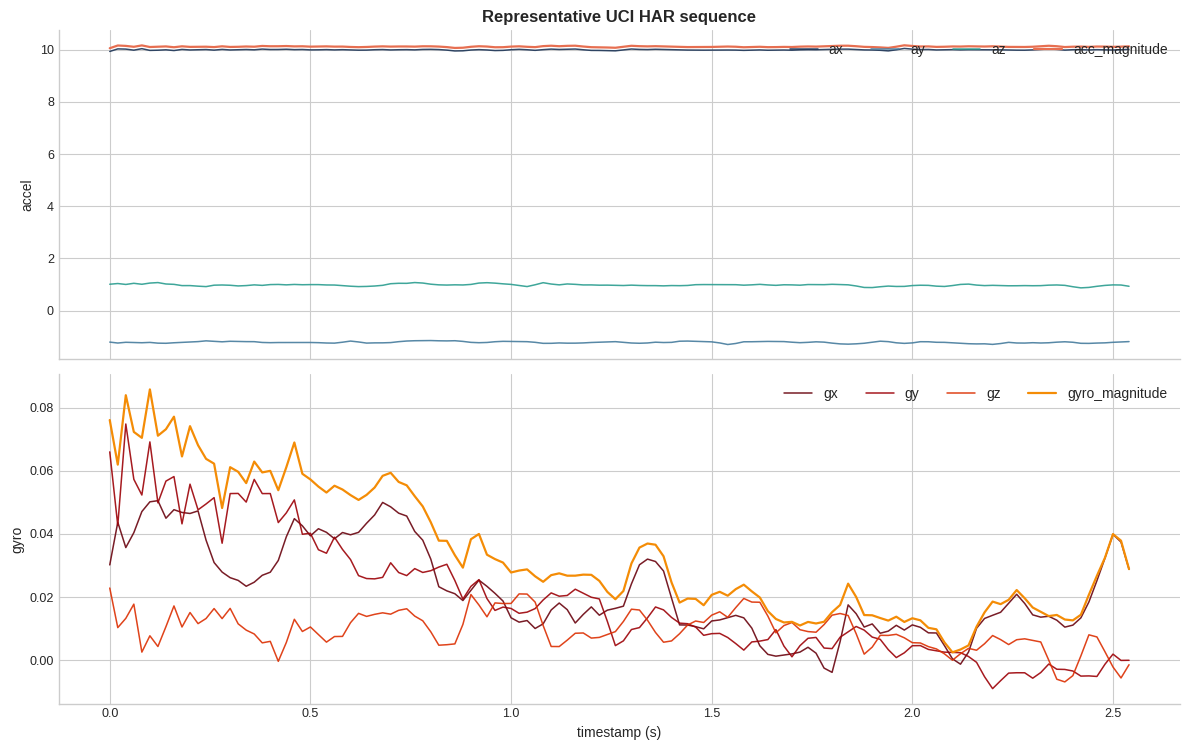

In [14]:
example_seq = nb_utils.pick_representative_sequence(df, preferred_label="locomotion", min_rows=64)
display(example_seq[["subject_id", "session_id", "timestamp", "ax", "ay", "az", "gx", "gy", "gz", "label_mapped"]].head(12))
_ = nb_utils.plot_sequence_axes(example_seq, title="Representative UCI HAR sequence")
